# Automotive Part Image-Text Matching — Dataset V3

## Final Deep Learning Exam Report

This report presents the final preserved evidence for an automotive-part image-text relation classifier.

The model predicts:

- **MATCH** — image and text describe the same part;
- **PARTIAL_MATCH** — different parts from the same broad subsystem;
- **MISMATCH** — parts from different subsystems.

The model and development notebook were frozen before test access. The locked test was evaluated exactly once. This notebook only reads the saved development and final-test artifacts; it does not train a model or run inference.


## 1. Problem and research question

Automotive catalogues and warehouses depend on product photographs agreeing with written descriptions. Incorrect pairs can create listing errors, picking mistakes, and avoidable returns.

**Research question:** Can a compact multimodal neural model outperform image-only, text-only, and simple multimodal baselines on independently grouped automotive-part images?


In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
DEV_RESULTS = ROOT / "results" / "dataset_v3"
FINAL_RESULTS = ROOT / "results" / "dataset_v3_final_test"
MANIFESTS = ROOT / "data" / "manifests" / "dataset_v3"

model_comparison = pd.read_csv(DEV_RESULTS / "model_comparison.csv")
paired_comparisons = pd.read_csv(DEV_RESULTS / "paired_comparisons.csv")
validation_predictions = pd.read_csv(
    DEV_RESULTS / "multimodal_validation_predictions.csv"
)

test_metrics = json.loads(
    (FINAL_RESULTS / "test_metrics.json").read_text(encoding="utf-8-sig")
)
test_predictions = pd.read_csv(FINAL_RESULTS / "test_predictions.csv")
test_per_category = pd.read_csv(FINAL_RESULTS / "test_per_category.csv")
test_confusion = pd.read_csv(
    FINAL_RESULTS / "test_confusion_matrix.csv",
    index_col=0,
)
authorization_consumption = json.loads(
    (FINAL_RESULTS / "authorization_consumption.json").read_text(
        encoding="utf-8-sig"
    )
)
selection_lock = json.loads(
    (MANIFESTS / "dataset_v3_final_selection_lock.json").read_text(
        encoding="utf-8-sig"
    )
)
results_manifest = json.loads(
    (MANIFESTS / "dataset_v3_final_test_results.json").read_text(
        encoding="utf-8-sig"
    )
)

print("Development models:", len(model_comparison))
print("Final model:", test_metrics["model_slug"])
print("Final test status:", test_metrics["status"])
print(
    "Final reporting mode: saved artifacts only; "
    "no training or inference is executed."
)


Development models: 7
Final model: torch_multimodal_dataset_v3
Final test status: PASS_DATASET_V3_FINAL_TEST_EVALUATION_COMPLETE
Final reporting mode: saved artifacts only; no training or inference is executed.


## 2. Dataset and independent evaluation unit

Dataset V3 contains 640 curated images across eight categories: alternator, brake disc, brake pad, coil spring, headlight, oil filter, starter, and taillight.

The project ignores the original source split and uses a deterministic 60/10/10 image split per category. Every image creates six balanced relation rows: two for each relation label. Because those rows share one image, the complete image group is the independent statistical unit.


In [2]:
split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "independent_images": 480,
            "images_per_category": 60,
            "relation_rows": 2880,
            "purpose": "training",
        },
        {
            "split": "validation",
            "independent_images": 80,
            "images_per_category": 10,
            "relation_rows": 480,
            "purpose": "model comparison and selection",
        },
        {
            "split": "locked test",
            "independent_images": test_metrics["test_images"],
            "images_per_category": test_metrics["test_images"] // 8,
            "relation_rows": test_metrics["test_rows"],
            "purpose": "one final evaluation",
        },
    ]
)
display(split_summary)
print(
    "Final relation balance:",
    test_metrics["relation_protocol"]["rows_per_label"],
    "rows per label.",
)


,split,independent_images,images_per_category,relation_rows,purpose
0,train,480,60,2880,training
1,validation,80,10,480,model comparison and selection
2,locked test,80,10,480,one final evaluation


Final relation balance: 160 rows per label.


## 3. Development model comparison and frozen selection

Seven baselines and neural models were compared on the 80-image validation split. Validation was used for model selection, so it is development evidence rather than an unbiased final estimate.

The selected checkpoint is `torch_multimodal_dataset_v3`. The frozen selection record binds the checkpoint, development notebook, data manifests, training artifacts, and implementation files before any locked-test evaluation.


In [3]:
preferred_columns = [
    "model_slug",
    "validation_accuracy",
    "validation_macro_f1",
    "correct_predictions",
    "total_predictions",
    "validation_images",
]
comparison_columns = [
    column for column in preferred_columns if column in model_comparison.columns
]
comparison = model_comparison[comparison_columns].copy()
if "validation_accuracy" in comparison.columns:
    comparison = comparison.sort_values(
        "validation_accuracy",
        ascending=False,
    )
display(comparison.reset_index(drop=True))

selected = model_comparison.set_index("model_slug").loc[
    "torch_multimodal_dataset_v3"
]
print(
    f"Selected validation result: "
    f"{selected.validation_accuracy:.4f} accuracy, "
    f"{selected.validation_macro_f1:.4f} macro F1, "
    f"{int(selected.correct_predictions)}/"
    f"{int(selected.total_predictions)} correct."
)
print("Selection basis:", selection_lock["selection_basis"])
print("Further tuning permitted:", selection_lock["further_tuning_permitted"])


,model_slug,validation_accuracy,validation_macro_f1,correct_predictions,total_predictions,validation_images
0,torch_multimodal_dataset_v3,0.785417,0.787284,377,480,80
1,torch_text_dataset_v3,0.333333,0.292270,160,480,80
2,torch_cnn_image_dataset_v3,0.333333,0.266627,160,480,80
3,image_text_logistic_regression,0.333333,0.166667,160,480,80
4,image_logistic_regression,0.333333,0.166667,160,480,80
5,majority,0.333333,0.166667,160,480,80
6,tfidf_logistic_regression,0.333333,0.166667,160,480,80


Selected validation result: 0.7854 accuracy, 0.7873 macro F1, 377/480 correct.
Selection basis: development_validation_only
Further tuning permitted: False


## 4. One-time locked-test protocol

After model selection was frozen, a separate authorization permitted exactly one final evaluation. The evaluator produced nine result artifacts and consumed the authorization.

No checkpoint replacement, post-test model selection, or further tuning is permitted. The final test result may be used only for reporting and error analysis.


In [4]:
protocol_summary = pd.DataFrame(
    [
        {
            "authorization_consumed": authorization_consumption[
                "authorization_consumed"
            ],
            "evaluations_completed": authorization_consumption[
                "authorized_evaluations_completed"
            ],
            "test_images_read": authorization_consumption["test_images_read"],
            "test_evaluation_executed": authorization_consumption[
                "test_evaluation_executed"
            ],
            "further_tuning_permitted": authorization_consumption[
                "further_tuning_permitted"
            ],
            "results_use": test_metrics["test_results_use"],
        }
    ]
)
display(protocol_summary)


,authorization_consumed,evaluations_completed,test_images_read,test_evaluation_executed,further_tuning_permitted,results_use
0,True,1,True,True,False,final_reporting_and_error_analysis_only


## 5. Final locked-test metrics

The final result below comes from the frozen checkpoint evaluated once on 80 independent test images and 480 balanced relation rows.


In [5]:
metric_summary = pd.DataFrame(
    [
        {
            "model": test_metrics["model_slug"],
            "independent_images": test_metrics["test_images"],
            "relation_rows": test_metrics["test_rows"],
            "correct": test_metrics["correct_predictions"],
            "accuracy": test_metrics["accuracy"],
            "macro_f1": test_metrics["macro_f1"],
            "accuracy_ci_low": test_metrics["accuracy_ci"][0],
            "accuracy_ci_high": test_metrics["accuracy_ci"][1],
            "macro_f1_ci_low": test_metrics["macro_f1_ci"][0],
            "macro_f1_ci_high": test_metrics["macro_f1_ci"][1],
        }
    ]
)
display(metric_summary)

display(
    Markdown(
        f"**Final result:** **{test_metrics['correct_predictions']}/"
        f"{test_metrics['test_rows']} correct**, "
        f"**accuracy {test_metrics['accuracy']:.4f}**, "
        f"**macro F1 {test_metrics['macro_f1']:.4f}**. "
        f"The grouped 95% accuracy interval is "
        f"**[{test_metrics['accuracy_ci'][0]:.4f}, "
        f"{test_metrics['accuracy_ci'][1]:.4f}]**."
    )
)


,model,independent_images,relation_rows,correct,accuracy,macro_f1,accuracy_ci_low,accuracy_ci_high,macro_f1_ci_low,macro_f1_ci_high
0,torch_multimodal_dataset_v3,80,480,354,0.7375,0.73823,0.660417,0.814583,0.653621,0.810187


**Final result:** **354/480 correct**, **accuracy 0.7375**, **macro F1 0.7382**. The grouped 95% accuracy interval is **[0.6604, 0.8146]**.

## 6. Per-label classification report


In [6]:
label_rows = []
for label in ("MATCH", "PARTIAL_MATCH", "MISMATCH"):
    values = test_metrics["classification_report"][label]
    label_rows.append(
        {
            "label": label,
            "precision": values["precision"],
            "recall": values["recall"],
            "f1": values["f1-score"],
            "support": int(values["support"]),
        }
    )
classification_table = pd.DataFrame(label_rows)
display(classification_table)


,label,precision,recall,f1,support
0,MATCH,0.798658,0.74375,0.770227,160
1,PARTIAL_MATCH,0.769231,0.68750,0.726073,160
2,MISMATCH,0.664894,0.78125,0.718391,160


## 7. Confusion matrix

The confusion matrix shows the saved final predictions. It is not recomputed by loading the model; it is read from the preserved final-test artifact.


,predicted_MATCH,predicted_MISMATCH,predicted_PARTIAL_MATCH
true_MATCH,119,30,11
true_MISMATCH,13,125,22
true_PARTIAL_MATCH,17,33,110


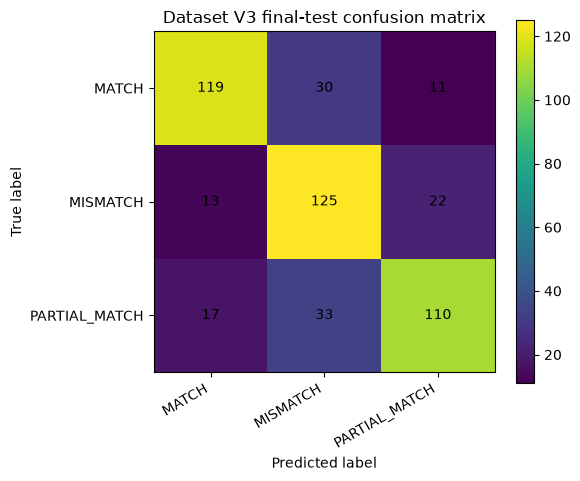

In [7]:
display(test_confusion)

matrix = test_confusion.to_numpy()
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix)
ax.set_xticks(range(len(test_confusion.columns)))
ax.set_xticklabels(
    [column.replace("predicted_", "") for column in test_confusion.columns],
    rotation=30,
    ha="right",
)
ax.set_yticks(range(len(test_confusion.index)))
ax.set_yticklabels(
    [index.replace("true_", "") for index in test_confusion.index]
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Dataset V3 final-test confusion matrix")
for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        ax.text(column, row, int(matrix[row, column]), ha="center", va="center")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


## 8. Per-category performance

Each category contributes ten independent test images and sixty relation rows. Per-category results help show where the compact model is strongest and where more varied training data may be useful.


,part_category,samples,independent_images,correct,accuracy,macro_f1
0,brake_pad,60,10,58,0.966667,0.966583
1,alternator,60,10,57,0.950000,0.950653
2,taillight,60,10,53,0.883333,0.884370
3,coil_spring,60,10,49,0.816667,0.820842
4,brake_disc,60,10,43,0.716667,0.716234
5,starter,60,10,35,0.583333,0.582694
6,oil_filter,60,10,30,0.500000,0.504202
7,headlight,60,10,29,0.483333,0.487733


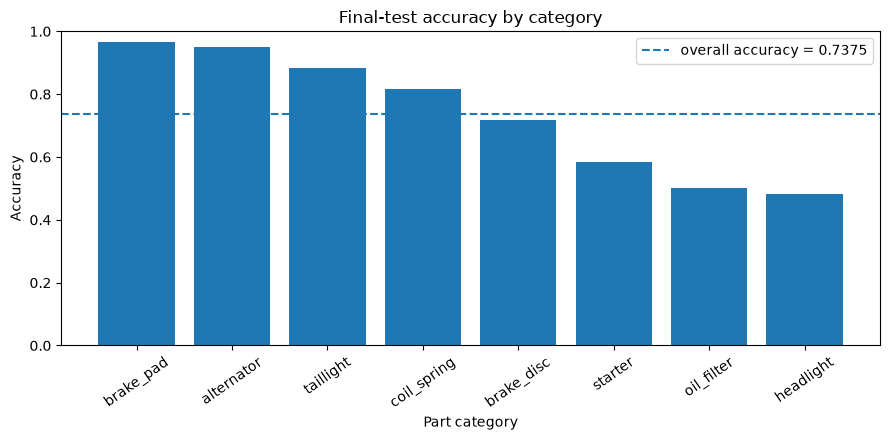

In [8]:
category_table = test_per_category.sort_values(
    "accuracy",
    ascending=False,
).reset_index(drop=True)
display(category_table)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(category_table["part_category"], category_table["accuracy"])
ax.axhline(
    test_metrics["accuracy"],
    linestyle="--",
    label=f"overall accuracy = {test_metrics['accuracy']:.4f}",
)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Part category")
ax.set_title("Final-test accuracy by category")
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.tight_layout()
plt.show()


## 9. Final error analysis

The analysis below uses only the saved `test_predictions.csv` file. It summarizes relation-label confusions and displays a small table of representative mistakes without reopening images or running the model.


In [9]:
errors = test_predictions.loc[
    test_predictions["true_label"].ne(
        test_predictions["predicted_label"]
    )
].copy()

error_matrix = pd.crosstab(
    errors["true_label"],
    errors["predicted_label"],
    margins=True,
)
display(error_matrix)

available_columns = [
    column
    for column in [
        "image_id",
        "part_category",
        "text_category",
        "description",
        "true_label",
        "predicted_label",
    ]
    if column in errors.columns
]
representative_errors = (
    errors[available_columns]
    .sort_values(
        [
            column
            for column in [
                "part_category",
                "true_label",
                "predicted_label",
                "image_id",
            ]
            if column in available_columns
        ]
    )
    .head(15)
)
display(representative_errors)

print("Saved final-test errors:", len(errors))
print(
    "Error rate:",
    f"{len(errors) / len(test_predictions):.4f}",
)


predicted_label,MATCH,MISMATCH,PARTIAL_MATCH,All
true_label,,,,
MATCH,0,30,11,41
MISMATCH,13,0,22,35
PARTIAL_MATCH,17,33,0,50
All,30,63,33,126


,image_id,part_category,text_category,description,true_label,predicted_label
41,kaggle_87d2d0ea0064d8c1,alternator,brake_disc,"This vehicle part is a brake disc or rotor, re...",MISMATCH,MATCH
37,kaggle_87d2d0ea0064d8c1,alternator,starter,A automotive starter motor from the engine-sup...,PARTIAL_MATCH,MATCH
40,kaggle_87d2d0ea0064d8c1,alternator,starter,This vehicle part is a automotive starter moto...,PARTIAL_MATCH,MATCH
96,kaggle_0c31e6ce13e74926,brake_disc,brake_disc,A brake disc or rotor from the vehicle chassis...,MATCH,MISMATCH
99,kaggle_0c31e6ce13e74926,brake_disc,brake_disc,"This vehicle part is a brake disc or rotor, re...",MATCH,MISMATCH
66,kaggle_3daceab8eae4bc5f,brake_disc,brake_disc,"This vehicle part is a brake disc or rotor, re...",MATCH,MISMATCH
69,kaggle_3daceab8eae4bc5f,brake_disc,brake_disc,A brake disc or rotor from the vehicle chassis...,MATCH,MISMATCH
102,kaggle_9561cc8d1347f616,brake_disc,brake_disc,"This vehicle part is a brake disc or rotor, re...",MATCH,MISMATCH
68,kaggle_3daceab8eae4bc5f,brake_disc,starter,This vehicle part is a automotive starter moto...,MISMATCH,MATCH
71,kaggle_3daceab8eae4bc5f,brake_disc,starter,A automotive starter motor from the engine-sup...,MISMATCH,MATCH


Saved final-test errors: 126
Error rate: 0.2625


## 10. Integrity checks

These checks confirm that the final report is based on the expected preserved evidence:

- the pre-test development notebook remains byte-identical to the frozen selection record;
- the saved prediction count and independent image count match the final metrics;
- the reported metrics match the recorded values;
- the one-time authorization is consumed;
- further tuning is disabled;
- this report contains no training or inference step.


In [10]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

frozen_notebook_path = ROOT / "project_v3.ipynb"
frozen_notebook_sha256 = sha256(frozen_notebook_path)

assert frozen_notebook_sha256 == selection_lock["selected_notebook_sha256"]
assert test_metrics["status"] == (
    "PASS_DATASET_V3_FINAL_TEST_EVALUATION_COMPLETE"
)
assert test_metrics["model_slug"] == selection_lock["selected_model_slug"]
assert len(test_predictions) == test_metrics["test_rows"]
assert test_predictions["image_id"].nunique() == test_metrics["test_images"]
assert int(
    test_predictions["true_label"]
    .eq(test_predictions["predicted_label"])
    .sum()
) == test_metrics["correct_predictions"]
assert np.isclose(test_metrics["accuracy"], 0.7375, atol=1e-12)
assert np.isclose(
    test_metrics["macro_f1"],
    0.7382299830250852,
    atol=1e-12,
)
assert authorization_consumption["authorization_consumed"] is True
assert authorization_consumption["authorized_evaluations_completed"] == 1
assert authorization_consumption["further_tuning_permitted"] is False
assert test_metrics["post_test_tuning_permitted"] is False
assert test_metrics["test_results_may_be_used_for_tuning"] is False
assert results_manifest["status"] == (
    "PASS_DATASET_V3_FINAL_TEST_RESULTS_RECORDED"
)

print("Final report integrity checks: PASS")
print("Frozen development notebook SHA-256:", frozen_notebook_sha256)


Final report integrity checks: PASS
Frozen development notebook SHA-256: 4f87a9818cf91d1011b4b09794da086b6cc8fc9469e10d612a7c6ae6efb1900a


## 11. Limitations

- The dataset contains 640 curated images from one public source collection.
- The test set contains 80 independent images; the grouped confidence intervals therefore remain important.
- Text descriptions contain explicit part names, so the task is relation classification rather than open-vocabulary language understanding.
- Public source images may retain label noise or source-specific visual patterns despite curation.
- The compact model is trained from scratch rather than initialized from a large pretrained vision-language model.
- Validation was used for model selection. The locked test was evaluated once and cannot be reused for additional selection.


In [11]:
display(
    Markdown(
        "## 12. Conclusion\n\n"
        f"The frozen Dataset V3 multimodal model achieved "
        f"**{test_metrics['accuracy']:.4f} final-test accuracy** and "
        f"**{test_metrics['macro_f1']:.4f} macro F1**, with "
        f"**{test_metrics['correct_predictions']}/"
        f"{test_metrics['test_rows']} correct relation rows** across "
        f"**{test_metrics['test_images']} independent test images**. "
        f"The grouped 95% accuracy interval was "
        f"**[{test_metrics['accuracy_ci'][0]:.4f}, "
        f"{test_metrics['accuracy_ci'][1]:.4f}]**.\n\n"
        "The result supports the research question for this curated dataset: "
        "the compact multimodal model learned a useful interaction between "
        "image and text and substantially exceeded the simple baselines used "
        "during development. The conclusion is limited to the recorded data, "
        "protocol, and one-time test evaluation; no post-test tuning was "
        "performed."
    )
)


## 12. Conclusion

The frozen Dataset V3 multimodal model achieved **0.7375 final-test accuracy** and **0.7382 macro F1**, with **354/480 correct relation rows** across **80 independent test images**. The grouped 95% accuracy interval was **[0.6604, 0.8146]**.

The result supports the research question for this curated dataset: the compact multimodal model learned a useful interaction between image and text and substantially exceeded the simple baselines used during development. The conclusion is limited to the recorded data, protocol, and one-time test evaluation; no post-test tuning was performed.